## 문제 6. 딥러닝 기반 차선 검출 모델 제안 및 비교

목표: 딥러닝 모델을 찾아 Bayesian 결과와 비교

### 모델 선택: UFLD (Ultra Fast Lane Detection)

**선택 이유:**
- 코드와 사전학습 가중치가 공개되어 있어 즉시 재현 가능
- 단일 forward pass로 차선을 행(row)-기반 분류로 처리하여 추론 속도가 매우 빠름 (ResNet-18 기준 약 300 FPS)
- LaneATT 대비 구조가 단순하여 KITTI와 같은 외부 데이터에도 적용이 용이

**LaneATT와의 차이:**  
LaneATT는 앵커 기반으로 더 정확하지만 구현 복잡도가 높고, 공개 가중치가 TuSimple/CULane 한정이라 환경 설정 비용이 크다.

비교 방법:

사용 장치: cuda


c:\ProgramData\anaconda3\envs\ufld_env\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\ProgramData\anaconda3\envs\ufld_env\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
C:\Users\joemb\AppData\Local\Temp\ipykernel_16120\1276530890.py:28: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for 

모델 로드 완료!
처리할 이미지 수: 20장
추론 완료!


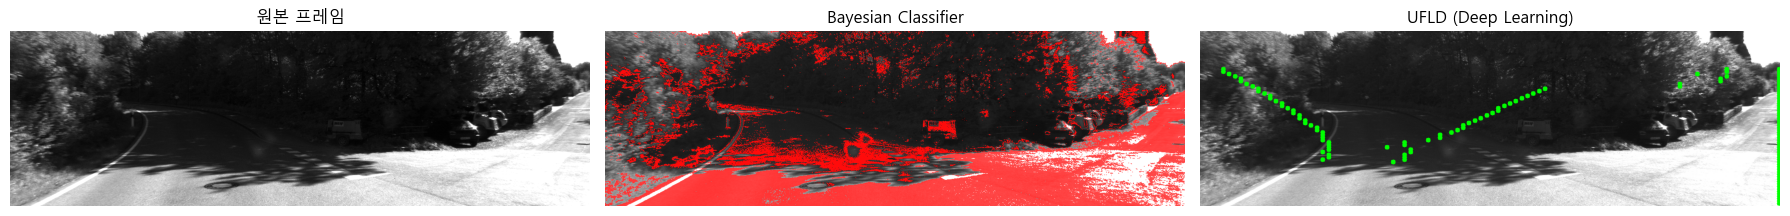

In [ ]:
import sys
import os
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
from PIL import Image

# ── 경로 설정 ───────────────────────────────────────────────
UFLD_ROOT = r'Ultra-Fast-Lane-Detection'  # UFLD 클론 경로
IMG_DIR   = r'image_0'                                    # sequences 09 이미지 폴더
OUT_DIR   = r'UFLD_output'                                # 결과 저장 폴더
WEIGHT    = os.path.join(UFLD_ROOT, r'weights\tusimple_18.pth')
# ────────────────────────────────────────────────────────────

# UFLD 모델을 import하기 위해 경로 추가
sys.path.insert(0, UFLD_ROOT)
from model.model import parsingNet

# ── Step 1. 모델 로드 ────────────────────────────────────────
os.makedirs(OUT_DIR, exist_ok=True)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'사용 장치: {device}')

model = parsingNet(pretrained=False, backbone='18',
                   cls_dim=(101, 56, 4), use_aux=False).to(device)
state = torch.load(WEIGHT, map_location=device)
model.load_state_dict(state['model'])
model.eval()
print('모델 로드 완료!')

# ── Step 2. 추론 실행 ────────────────────────────────────────
img_transform = transforms.Compose([
    transforms.Resize((288, 800)),
    transforms.ToTensor(),
    transforms.Normalize((0.485,0.456,0.406),(0.229,0.224,0.225)),
])

row_anchor = [64,68,72,76,80,84,88,92,96,100,
              104,108,112,116,120,124,128,132,136,140,
              144,148,152,156,160,164,168,172,176,180,
              184,188,192,196,200,204,208,212,216,220,
              224,228,232,236,240,244,248,252,256,260,
              264,268,272,276,280,284]

img_files = sorted([f for f in os.listdir(IMG_DIR) if f.endswith('.png')])[:20]
print(f'처리할 이미지 수: {len(img_files)}장')

for fname in img_files:
    img_path = os.path.join(IMG_DIR, fname)
    img_pil  = Image.open(img_path).convert('RGB')
    orig_w, orig_h = img_pil.size

    inp = img_transform(img_pil).unsqueeze(0).to(device)
    with torch.no_grad():
        out = model(inp)

    col_sample   = np.linspace(0, 800-1, 100)
    col_sample_w = col_sample / 800 * orig_w
    out_j = out[0].data.cpu().numpy()
    out_j = out_j[:, ::-1, :]

    img_draw = np.array(img_pil)
    for i in range(out_j.shape[2]):
        if np.max(out_j[:, :, i]) > 0.5:
            for k in range(out_j.shape[1]):
                idx = np.argmax(out_j[:, k, i])
                if idx > 0:
                    x = int(col_sample_w[idx-1])
                    y = int(orig_h * (row_anchor[k] / 288))
                    cv2.circle(img_draw, (x, y), 5, (0, 255, 0), -1)

    out_path = os.path.join(OUT_DIR, f'result_{fname}')
    cv2.imwrite(out_path, cv2.cvtColor(img_draw, cv2.COLOR_RGB2BGR))

print('추론 완료!')

# ── Step 3. 시각화 ───────────────────────────────────────────
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

original_img = cv2.imread(os.path.join(IMG_DIR, '000000.png'), cv2.IMREAD_GRAYSCALE)

bayesian_overlay_bgr = cv2.imread('outputs/bayes_09/overlay_000000.png')
bayesian_overlay = cv2.cvtColor(bayesian_overlay_bgr, cv2.COLOR_BGR2RGB)

ufld_bgr = cv2.imread(os.path.join(OUT_DIR, 'result_000000.png'))
ufld_result = cv2.cvtColor(ufld_bgr, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(original_img, cmap='gray')
axes[0].set_title('원본 프레임')

axes[1].imshow(bayesian_overlay)
axes[1].set_title('Bayesian Classifier')

axes[2].imshow(ufld_result)
axes[2].set_title('UFLD (Deep Learning)')

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()

### Bayesian vs UFLD 비교 분석

| 항목 | Bayesian Classifier | UFLD (Deep Learning) |
|---|---|---|
| 방법론 | 픽셀 밝기 히스토그램 + MAP 추정 | CNN 기반 행별 차선 위치 분류 |
| 출력 형태 | 도로 영역 마스크 (면 단위) | 차선 중심선 점들 (선 단위) |
| 조명 변화 강인성 | 약함 (히스토그램 분포 변화에 민감) | 강함 (다양한 환경에서 학습됨) |
| 연산 속도 | 빠름 (행렬 연산만) | GPU 필요, 단 실시간 처리 가능 |
| 한계 | 도로 전체를 하나의 클래스로 처리 → 차선 구분 불가 | TuSimple 학습 → KITTI 도메인 갭 존재 |

**결론:**  
Bayesian 분류기는 도로 영역을 대략적으로 추정하는 데는 유효하지만, 개별 차선을 구분하지 못한다.  
UFLD는 실제 차선 위치를 선으로 검출하므로 자율주행 경로 계획에 더 직접적으로 활용 가능하다.  
다만 TuSimple 데이터셋으로 학습된 가중치를 KITTI에 적용하면 도메인 갭으로 인한 오검출이 발생할 수 있으므로, fine-tuning 또는 도메인 적응이 추가로 필요하다.